In [123]:
#time
#flux
#redshift
#distance

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math
import sklearn.mixture as mix
from sklearn import datasets
from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl
from sklearn.metrics import accuracy_score
import emcee
#import warnings; warnings.simplefilter('ignore')
import time
import corner

In [125]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [126]:
#cleaning the data from no actual data (-999 values) and transform them from strings to floats
time = np.float64(data[names=='T90'][(data[names=='T90']!='-999')&(data[names=='fluence']!='-999')])
flux = np.float64(data[names=='fluence'][(data[names=='T90']!='-999')&(data[names=='fluence']!='-999')])
flux_rs = np.float64(data[names=='fluence'][(data[names=='redshift']!='-999')&(data[names=='fluence']!='-999')])
rs = np.float64(data[names=='redshift'][(data[names=='fluence']!='-999')&(data[names=='redshift']!='-999')])

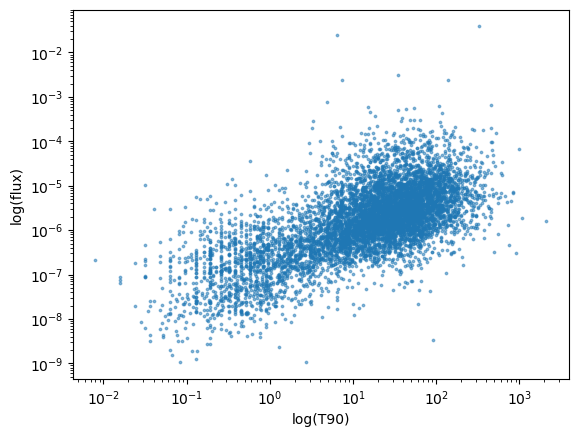

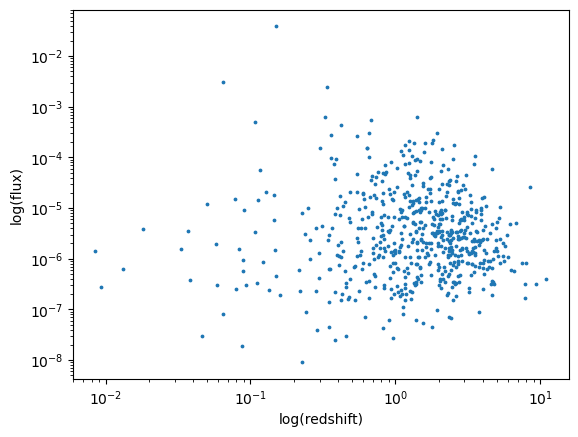

In [127]:
plt.scatter(time, flux, s=3, alpha=0.5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('log(T90)')
plt.ylabel('log(flux)')
plt.show()
plt.scatter(rs, flux_rs, s=3, alpha=1)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('log(redshift)')
plt.ylabel('log(flux)')
plt.show()

Flux ('fluence') and emission duration ('T90') seems to underlying better the multi-modality of the distribution.

From the first plot it looks like the distribution contains two populations (infact we know two types of gamma-ray burst: shorts(<2s) and long(>2s)).

# K-means

In [128]:
#select the data != 0 for the conversion in log10 for the right functionality of the kmeans!
X = np.vstack([np.log10(time[(time!=0) & (flux!=0)]), np.log10(flux[(time!=0) & (flux!=0)])]).T
X_rs = np.vstack([np.log10(rs[(rs!=0) & (flux_rs!=0)]), np.log10(flux_rs[(rs!=0) & (flux_rs!=0)])]).T

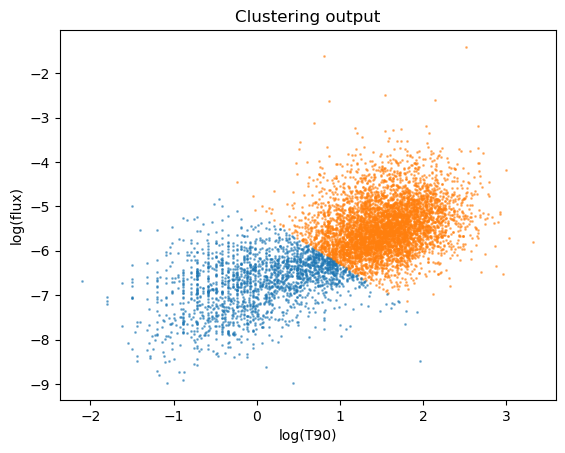

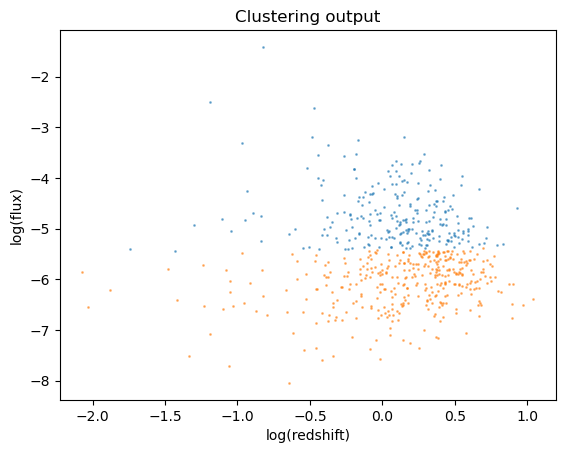

In [129]:
from sklearn.cluster import KMeans
from sklearn import preprocessing


#T90 and flux

clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], color=colors[ii],alpha=0.5, s=1)

plt.xlabel('log(T90)')
plt.ylabel('log(flux)')
plt.title('Clustering output')
plt.show()



#redshift and flux

clf_rs = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf_rs.fit(X_rs)
centers_rs = clf_rs.cluster_centers_ #location of the clusters
labels_rs = clf_rs.predict(X_rs) #labels for each of the points

# plot the data color-coded by cluster id
colors_rs = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X_rs[labels_rs==ii,0], X_rs[labels_rs==ii,1], color=colors_rs[ii],alpha=0.5, s=1)

plt.xlabel('log(redshift)')
plt.ylabel('log(flux)')
plt.title('Clustering output')
plt.show()

### With 2D histogram

In [130]:
#The StandardScaler transforms data so that its distribution has a mean of 0 and a standard deviation of 1.
#This is a crucial step in many machine learning algorithms, especially K-Means, because it prevents 
#features with larger scales from dominating the clustering process.

n_clusters = 2
scaler = preprocessing.StandardScaler()
clf = KMeans(n_clusters, n_init='auto')
clf.fit(scaler.fit_transform(X))

KMeans(n_clusters=2)

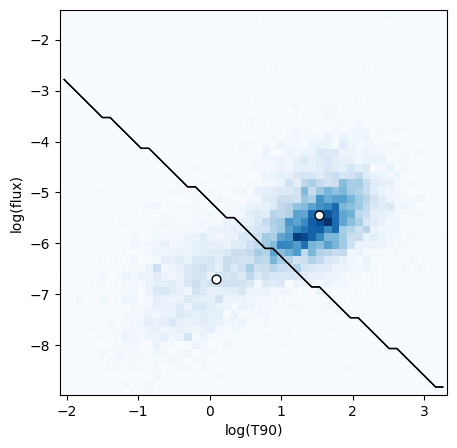

In [131]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto', 
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(clf.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = clf.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5], linewidths=1, colors='k')

    H = clf.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('log(T90)')
ax.set_ylabel('log(flux)')

plt.show()

# Mean-shift

### with estimated bandwidth

In [186]:
scaler = preprocessing.StandardScaler()
s_X = scaler.fit_transform(X)

In [195]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X)

ms = MeanShift(bandwidth=bandwidth)
ms.fit(s_X)
labels = ms.labels_
s_cluster_centers = ms.cluster_centers_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

print("number of estimated clusters : %d" % n_clusters_)
cluster_centers = scaler.inverse_transform(s_cluster_centers)

number of estimated clusters : 4


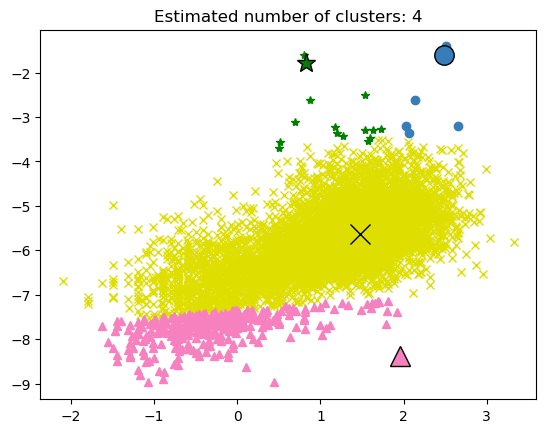

In [196]:
plt.figure(1)
plt.clf()

colors = ["#dede00", "#377eb8", "#f781bf", "green"]
markers = ["x", "o", "^", "*"]

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    cluster_center = cluster_centers[k]
    plt.plot(X[my_members, 0], X[my_members, 1], markers[k], color=col)
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        markers[k],
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=14,
    )
plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

Preatty bad clusering..

### with hand-choosen bandwidth

In [134]:
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
bandwidth = 1
#bandwidth = estimate_bandwidth(X_reduced) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, seeds=X, cluster_all=False)
ms.fit(scaler.fit_transform(X))

MeanShift(bandwidth=1, bin_seeding=True, cluster_all=False,
          seeds=array([[ 1.24708906, -5.0209709 ],
       [ 0.92675391, -4.5438618 ],
       [ 1.73865374, -5.80681973],
       ...,
       [ 0.49637605, -7.60453382],
       [ 2.31926433, -6.78225293],
       [ 0.71466499, -5.58410892]]))

[-1  0  1]
1
number of estimated clusters : 2


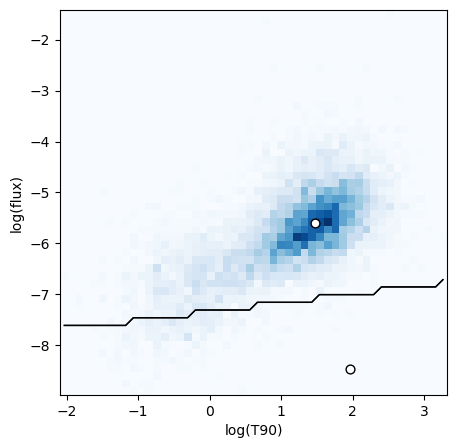

[[ 1.46681135 -5.61018141]
 [ 1.96151601 -8.47790804]]


In [135]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >=0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)
N=50
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], N)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, N * N)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((N, N))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5], linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((N, N))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('log(T90)')
ax.set_ylabel('log(flux)')

plt.show()
print(cluster_centers)

Maybe it doesn't respond well to outliers, cause it is not able to well detect the center of the left cluster. Let's try to cut out them.

## Cutting out outliers:

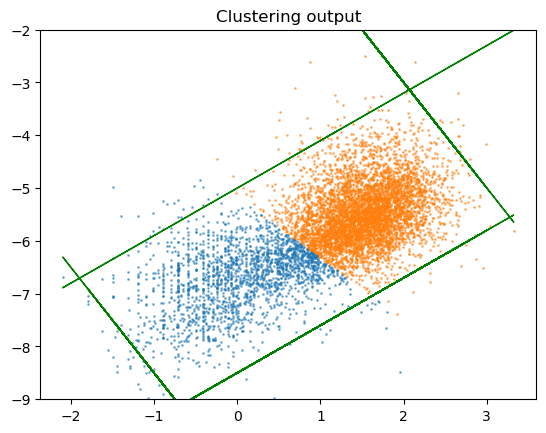

In [136]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], color=colors[ii],alpha=0.5, s=1)

x_f = X[:,0]
y_dw = (0.9)*x_f -8.5
plt.plot(x_f,y_dw, 'green', lw=1)

y_up = (0.9)*x_f -5
plt.plot(x_f,y_up, 'green', lw=1)

y_r = (-2)*x_f + 1
plt.plot(x_f,y_r, 'green', lw=1)

y_l = (-2)*x_f - 10.5
plt.plot(x_f,y_l, 'green', lw=1)

plt.title('Clustering output')
plt.ylim(-9,-2)
plt.show()

In [137]:
X_cut = X[((0.9*X[:,0] -8.5)<X[:,1]) & (X[:,1]<(0.9*X[:,0] -5)) & ((-2*X[:,0] -10.5)<X[:,1]) & ((-2*X[:,0] +1)>X[:,1])]

### with estimated bandwidth

In [191]:
scaler = preprocessing.StandardScaler()
s_X_cut = scaler.fit_transform(X_cut)

In [197]:
bandwidth = estimate_bandwidth(X_cut)
ms = MeanShift(bandwidth=bandwidth)
ms.fit(s_X_cut)
labels = ms.labels_
s_cluster_centers = ms.cluster_centers_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

print("number of estimated clusters : %d" % n_clusters_)
cluster_centers = scaler.inverse_transform(s_cluster_centers)
print(cluster_centers)

number of estimated clusters : 1
[[ 1.4698772  -5.61909282]]


Very bad.. it estimates just one cluster

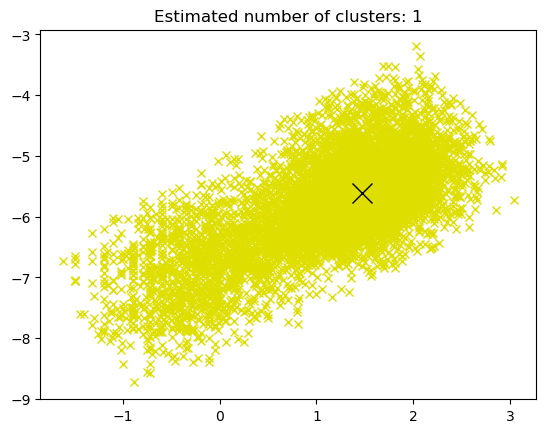

In [198]:
plt.figure(1)
plt.clf()

colors = ["#dede00", "#377eb8", "#f781bf", "green"]
markers = ["x", "o", "^", "*"]

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    cluster_center = cluster_centers[k]
    plt.plot(X_cut[my_members, 0], X_cut[my_members, 1], markers[k], color=col)
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        markers[k],
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=14,
    )
plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

### with hand-choosen bandwidth

In [140]:
bw_cut = 0.51
#bandwidth = estimate_bandwidth(X_reduced) # this takes a long time...beware
ms_cut = MeanShift(bandwidth=bw_cut, bin_seeding=True, cluster_all=False)
ms_cut.fit(scaler.fit_transform(X_cut))

MeanShift(bandwidth=0.51, bin_seeding=True, cluster_all=False)

[-1  0  1]
0.51
number of estimated clusters : 2


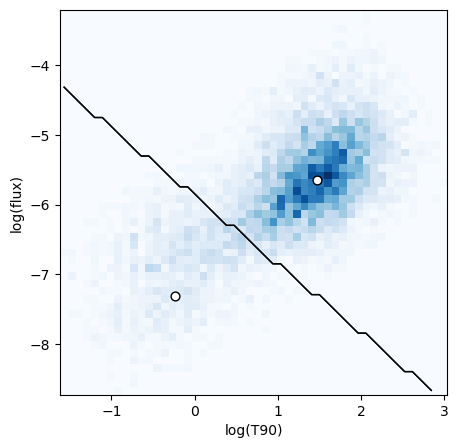

[[ 1.47652775 -5.64713778]
 [-0.23424246 -7.31944785]]


In [141]:
labels_unique = np.unique(ms_cut.labels_)
n_clusters = len(labels_unique[labels_unique >=0])
print(labels_unique)
print(bw_cut)
print("number of estimated clusters :", n_clusters)
N=50
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X_cut[:,0], X_cut[:,1], N)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms_cut.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, N * N)).T

H = ms_cut.predict(scaler.transform(Xgrid)).reshape((N, N))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5], linewidths=1, colors='k')
 
    H = ms_cut.predict(scaler.transform(Xgrid)).reshape((N, N))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('log(T90)')
ax.set_ylabel('log(flux)')

plt.show()
print(cluster_centers)

Way better! It actually does not well responds to outlyers

# To underlying the two modes (long & short GRB), let's look at 'T90' alone

In [142]:
t = np.float64(data[names=='T90'][data[names=='T90']!='-999'])
lnt = np.log10(t[t!=0])

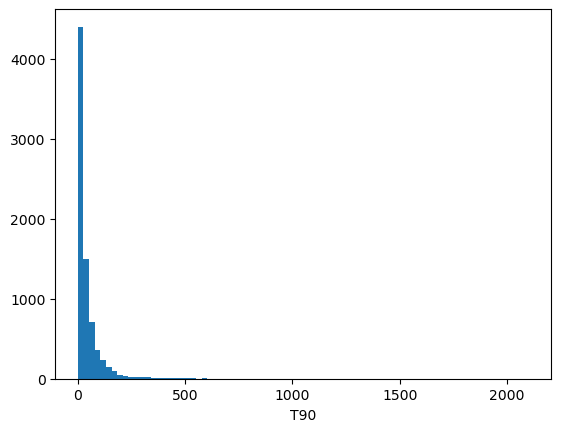

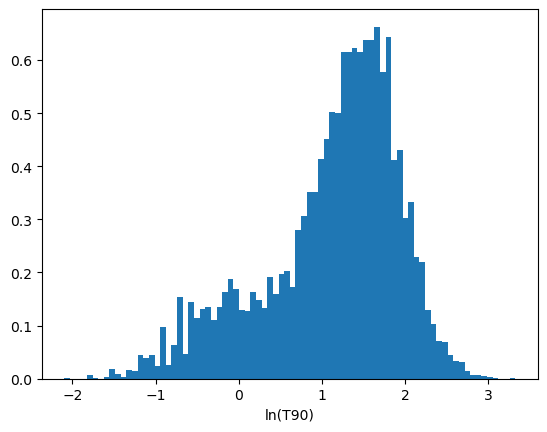

In [143]:
plt.hist(t, bins=80)
plt.xlabel('T90')
plt.show()
plt.hist(lnt, bins=80, density=True)
plt.xlabel('ln(T90)')
plt.show()

## Gaussian mixture

Let's finde the optimal number of components for the gaussian mixture form AIC and cross validation

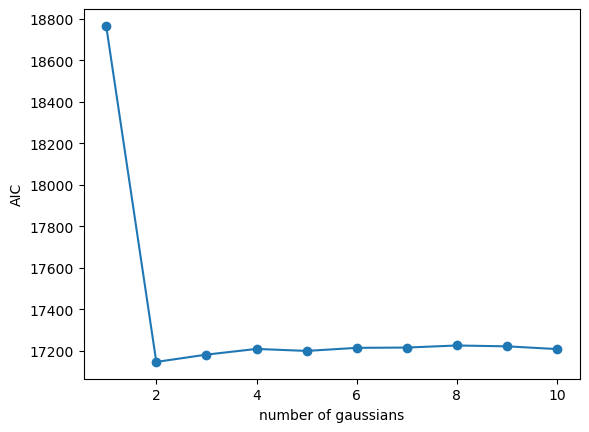

Optimal number of components through from AIC:  2


In [144]:
gm_N = []
N = np.linspace(1,10,10, dtype=int)
[gm_N.append(mix.GaussianMixture(n).fit(lnt[:,np.newaxis]).aic(lnt[:,np.newaxis])) for n in N]
plt.plot(N,gm_N, '-o')
plt.ylabel('AIC')
plt.xlabel('number of gaussians')
plt.show()
print('Optimal number of components through from AIC: ', N[np.argmin(gm_N)])

In [145]:
from sklearn.model_selection import GridSearchCV

K = 5 # Do 5-fold cross validation
grid = GridSearchCV(mix.GaussianMixture(), {'n_components': N}, cv= K) # Try each bandwidth with K-folds
grid.fit(lnt[:, np.newaxis])
n_opt_t90 = grid.best_params_['n_components']
print('Optimal number of components through cross validation: %i' % n_opt_t90)

Optimal number of components through cross validation: 2


Good! Through both AIC and CV we find a two-mode distribution for T90, as expected

C:\Users\balza\AppData\Local\Temp\ipykernel_69876\1943686006.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(decision_boundary, c='black', lw = 2, ls = ':', label = 'Decision boundary\n(%.2f s)' % 10**decision_boundary)


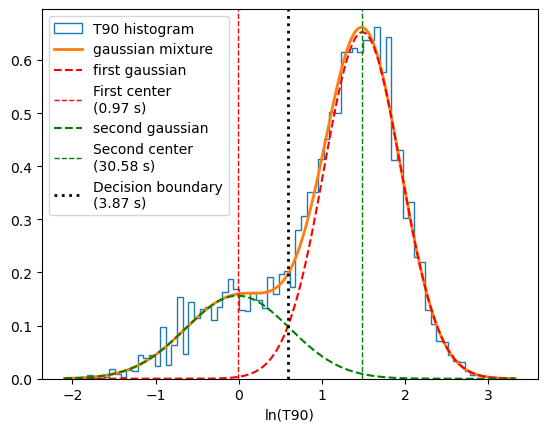

In [146]:
x = np.linspace(np.min(lnt[:,np.newaxis]),np.max(lnt[:,np.newaxis]),1000)[:,np.newaxis]
gm_min = mix.GaussianMixture(N[np.argmin(gm_N)]).fit(lnt[:,np.newaxis])
y_min = gm_min.score_samples(x)
gd = gm_min.predict_proba(x)

means = gm_min.means_.flatten()
order = np.argsort(means)
means_t90 = means[order]
contr_t90 = gm_min.predict_proba(x)[:, order]
decision_boundary = x[np.argmin(np.abs(contr_t90[:, 0] - contr_t90[:, 1]))]

plt.hist(lnt, bins=80, density=True, histtype="step", label='T90 histogram')
plt.xlabel('ln(T90)')
plt.plot(x, np.exp(y_min), lw=2, label='gaussian mixture')
plt.plot(x, gd[:,1]*np.exp(y_min), '--', c='red', label='first gaussian')
plt.axvline(means_t90[0], c='red', lw = 1, ls = '--', label = 'First center\n(%.2f s)' % 10**means_t90[0])
plt.plot(x, gd[:,0]*np.exp(y_min), '--', c='green', label='second gaussian')
plt.axvline(means_t90[1], c='green', lw = 1, ls = '--', label = 'Second center\n(%.2f s)' % 10**means_t90[1])
plt.axvline(decision_boundary, c='black', lw = 2, ls = ':', label = 'Decision boundary\n(%.2f s)' % 10**decision_boundary)

plt.legend()
plt.show()

## KDE

In [147]:
from sklearn.neighbors import KernelDensity

bwrange = np.linspace(0.01,1.0, 40) # Test 40 bandwidths from 0.1 to 1.0
K = 5 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(lnt[:, np.newaxis])
bw = grid.best_params_['bandwidth']
print(bw)

0.11153846153846153


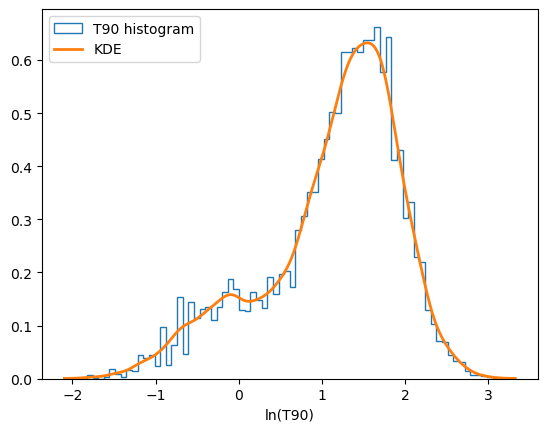

In [148]:
kde = KernelDensity(bandwidth = bw, kernel='gaussian').fit(lnt[:, np.newaxis])
y = np.exp(kde.score_samples(x))

plt.hist(lnt, bins=80, density=True, histtype="step", label='T90 histogram')
plt.plot(x, y, lw=2, label='KDE')
plt.xlabel('ln(T90)')
plt.legend()
plt.show()

### KMean

In [170]:
clf = KMeans(n_clusters=2, n_init='auto') #Try 2 clusters to start with
clf.fit(lnt[:,np.newaxis])

centers = clf.cluster_centers_ #location of the clusters
centers = 10**np.squeeze(centers)
centers #in seconds

array([33.07377181,  0.91541109])

In [171]:
labels = clf.predict(lnt[:,np.newaxis])

if centers[0]>centers[1]:
    centers=centers[::-1] # Reverse array
    labels = np.array(~np.array(labels,dtype='bool'),dtype='int')

boundary = 10**(np.mean([max(lnt[:,np.newaxis][labels==0]), min(lnt[:,np.newaxis][labels==1])]))
print(boundary)

5.501999636495807


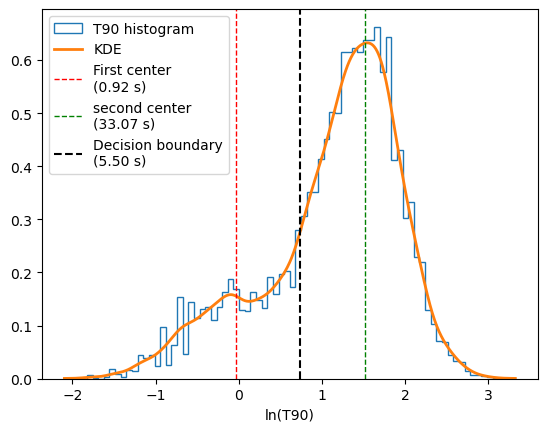

In [172]:
plt.hist(lnt, bins=80, density=True, histtype="step", label='T90 histogram')
plt.plot(x, y, lw=2, label='KDE')
plt.xlabel('ln(T90)')
plt.axvline(np.log10(centers[0]), c='red', lw = 1, ls = '--', label = 'First center\n(%.2f s)' % centers[0])
plt.axvline(np.log10(centers[1]), c='green', lw = 1, ls = '--', label = 'second center\n(%.2f s)' % centers[1])
plt.axvline(np.log10(boundary),c='black',ls='--', label = 'Decision boundary\n(%.2f s)' % boundary)
plt.legend()
plt.show()

### Mean-shift

In [155]:
scaler = preprocessing.StandardScaler()
scaled_lnt = scaler.fit_transform(lnt[:, np.newaxis])

In [156]:
bw = estimate_bandwidth(lnt[:,np.newaxis])

ms = MeanShift(bandwidth=bw)
ms.fit(scaled_lnt)
lb = ms.labels_
cc = ms.cluster_centers_

labels_unique = np.unique(lb)
n_clusters_ = len(labels_unique)

print("number of estimated clusters : %d" % n_clusters_)

number of estimated clusters : 2


In [158]:
labels_unique, cc

(array([0, 1], dtype=int64),
 array([[ 0.45967874],
        [-1.36544996]]))

In [167]:
if cc[0] > cc[1]:
    cc = cc[::-1]
    lb = np.array(~np.array(lb, dtype='bool'), dtype='int')

centers_ms = scaler.inverse_transform(cc)

db = np.mean([max(lnt[lb==0]), min(lnt[lb==1])])

C:\Users\balza\AppData\Local\Temp\ipykernel_69876\2529951230.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(centers_ms[0], c='red', lw = 1, ls = '--', label = 'First center\n(%.2f s)' % 10**centers_ms[0])
C:\Users\balza\AppData\Local\Temp\ipykernel_69876\2529951230.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(centers_ms[1], c='green', lw = 1, ls = '--', label = 'second center\n(%.2f s)' % 10**centers_ms[1])


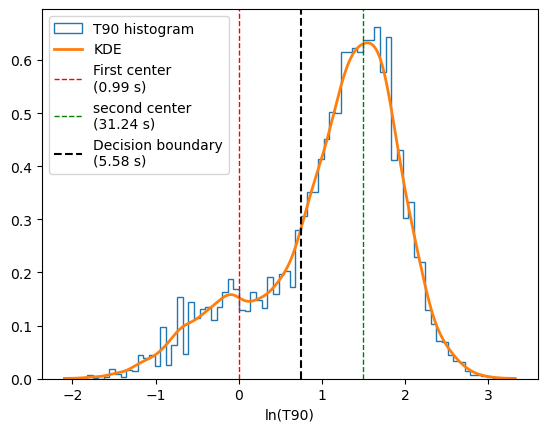

In [168]:
plt.hist(lnt, bins=80, density=True, histtype="step", label='T90 histogram')
plt.plot(x, y, lw=2, label='KDE')
plt.xlabel('ln(T90)')
plt.axvline(centers_ms[0], c='red', lw = 1, ls = '--', label = 'First center\n(%.2f s)' % 10**centers_ms[0])
plt.axvline(centers_ms[1], c='green', lw = 1, ls = '--', label = 'second center\n(%.2f s)' % 10**centers_ms[1])
plt.axvline(db,c='black',ls='--', label = 'Decision boundary\n(%.2f s)' % 10**db)
plt.legend()
plt.show()

But we didn't considered the errors! Let's see if it is ok to do that:

## Quick stats for center estimations

In [184]:
for l,gm,km,ms in zip(['Short GRBs','Long GRBs'],np.sort(10**means_t90),np.sort(centers),np.sort(np.squeeze(10**centers_ms))):    
    print(l," GaussianMixture & Kmean: ", gm, km, np.abs(gm-km)/np.mean([gm,km]))
    print(l," GaussianMixture & mean-shift: ", gm, ms, np.abs(gm-ms)/np.mean([gm,ms]))
    print(l," Kmean & mean-shift: ",km, ms, np.abs(km-ms)/np.mean([km,ms]))

Short GRBs  GaussianMixture & Kmean:  0.9695938724808137 0.9154110914817203 0.0574882104131906
Short GRBs  GaussianMixture & mean-shift:  0.9695938724808137 0.9948390375430768 0.025702242039872997
Short GRBs  Kmean & mean-shift:  0.9154110914817203 0.9948390375430768 0.08315973374848593
Long GRBs  GaussianMixture & Kmean:  30.576404905244896 33.07377180630861 0.07847164077426373
Long GRBs  GaussianMixture & mean-shift:  30.576404905244896 31.24156208796189 0.021519865989448893
Long GRBs  Kmean & mean-shift:  33.07377180630861 31.24156208796189 0.05697582854374161


# Errors

In [165]:
times = np.float64(data[names=='T90'][data[names=='T90']!='-999'])
times_err = np.float64(data[names=='T90_error'][data[names=='T90']!='-999'])
times = times[times_err>-10]
times_err = times_err[times_err>-10]

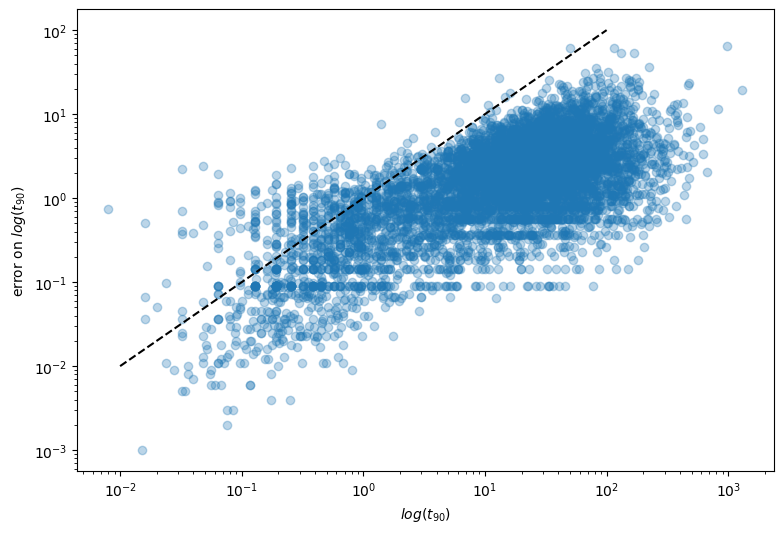

In [166]:
plt.figure(figsize = (9,6))
plt.scatter(times, times_err, alpha = 0.3)
plt.plot([1e-2,1e2],[1e-2,1e2], c = 'black', ls = '--')
plt.loglog()
plt.xlabel('$log(t_{90})$')
plt.ylabel('error on $log(t_{90})$')
plt.show()

We can observe how for large GRB it is actially ok to not consider the errors since they are way smaller than the T90 vale, but it is not true for small GRB.